# RF Fingerprinting — Master Training Notebook
**Thesis:** Lightweight Device Authentication in Wireless Communication Using RF Fingerprinting  
**University:** Kristianstad University (HKR) — DT339G VT26

---
### Dataset
| File | Device Serial | Class Label |
|------|--------------|-------------|
| `tx1_new.dat` | 3288FAD (TX role) | **0** |
| `tx1_Swap_new.dat` | 3288FF2 (TX role) | **1** |

Both captured over-the-air at 1 m, CW 10 kHz tone, 1 MHz sample rate, TX Gain: 0 dB, RX Gain: 30 dB.

### Pipeline
1. Mount Drive → Load raw IQ  
2. Preprocess (transient removal, normalization — **DC offset preserved**)  
3. Visualise & sanity-check both signals  
4. AWGN injection at 20 dB, 10 dB, 0 dB  
5. Build lightweight 1D-CNN (~52 K parameters)  
6. Train & evaluate at each SNR level  
7. Confusion matrices + per-SNR accuracy summary

## Step 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Imports & Reproducibility Seed

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os, random

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 3 — Configuration (Edit Paths Here If Needed)

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_PATH = '/content/drive/MyDrive/My Thesis/Recordings'
PATH_TX1  = os.path.join(BASE_PATH, 'tx1_new.dat')
PATH_TX2  = os.path.join(BASE_PATH, 'tx1_Swap_new.dat')

# ── Signal Parameters ───────────────────────────────────────────────────────
SAMPLE_RATE     = 1_000_000   # 1 MHz
TRANSIENT_SKIP  = 1_000_000   # drop first 1 second (hardware turn-on spike)
SEGMENT_LENGTH  = 1024        # samples per CNN input window

# ── Training SNR levels ─────────────────────────────────────────────────────
# 30 dB excluded: swap dataset real-world noise dominates at that level
SNR_LEVELS = [20, 10, 0]

# ── Training ────────────────────────────────────────────────────────────────
EPOCHS      = 20
BATCH_SIZE  = 64
TEST_SPLIT  = 0.20

print("Configuration loaded.")
print(f"  TX1 path : {PATH_TX1}")
print(f"  TX2 path : {PATH_TX2}")
print(f"  SNR levels to train : {SNR_LEVELS} dB")

Configuration loaded.
  TX1 path : /content/drive/MyDrive/My Thesis/Recordings/tx1_new.dat
  TX2 path : /content/drive/MyDrive/My Thesis/Recordings/tx1_Swap_new.dat
  SNR levels to train : [20, 10, 0] dB


## Step 4 — Preprocessing Function

**Key design decisions:**
- ✅ Drop first 1,000,000 samples (hardware transient)
- ✅ **No mean subtraction** — DC offset (LO leakage) is a hardware fingerprint feature
- ✅ Normalise by max absolute amplitude
- ✅ Reshape into (N, 1024, 2) segments — I and Q as separate channels

In [ ]:
def preprocess_iq(filename, segment_length=SEGMENT_LENGTH, transient_skip=TRANSIENT_SKIP):
    """
    Load a raw Complex Float32 IQ recording and return clean segments.

    Parameters
    ----------
    filename      : path to .dat file
    segment_length: samples per segment (default 1024)
    transient_skip: samples to discard at start (default 1,000,000)

    Returns
    -------
    segments : ndarray, shape (N, segment_length, 2)  — float32
    raw_iq   : complex64 array BEFORE segmentation (for visualisation)
    """
    print(f"  Loading  : {os.path.basename(filename)}")
    iq = np.fromfile(filename, dtype=np.complex64)
    print(f"  Samples  : {len(iq):,} total")

    # 1. Drop hardware turn-on transient
    iq = iq[transient_skip:]
    print(f"  After trim: {len(iq):,} samples")

    # 2. Normalise amplitude  (NO mean subtraction — DC offset preserved)
    iq = iq / np.max(np.abs(iq))

    # 3. Split into I / Q and segment
    iq_2d = np.column_stack((np.real(iq), np.imag(iq))).astype(np.float32)
    n_segments = len(iq_2d) // segment_length
    segments = iq_2d[:n_segments * segment_length].reshape(n_segments, segment_length, 2)

    print(f"  Segments : {n_segments:,}  shape={segments.shape}  dtype={segments.dtype}")
    return segments, iq   # return raw complex array too for plots


print("Preprocessing function defined.")

Preprocessing function defined.


## Step 5 — Load & Preprocess Both Devices

In [ ]:
print("=" * 55)
print("Device 0  (3288FAD) — tx1_new.dat")
print("=" * 55)
segs_tx1, raw_tx1 = preprocess_iq(PATH_TX1)

print()
print("=" * 55)
print("Device 1  (3288FF2) — tx1_Swap_new.dat")
print("=" * 55)
segs_tx2, raw_tx2 = preprocess_iq(PATH_TX2)

print()
print(f"Class 0 segments : {len(segs_tx1):,}")
print(f"Class 1 segments : {len(segs_tx2):,}")
print(f"Balance ratio    : {len(segs_tx1)/len(segs_tx2):.3f}  (1.000 = perfect)")

Device 0  (3288FAD) — tx1_new.dat
  Loading  : tx1_new.dat
  Samples  : 63,988,680 total
  After trim: 62,988,680 samples
  Segments : 61,512  shape=(61512, 1024, 2)  dtype=float32

Device 1  (3288FF2) — tx1_Swap_new.dat
  Loading  : tx1_Swap_new.dat
  Samples  : 64,592,520 total
  After trim: 63,592,520 samples
  Segments : 62,102  shape=(62102, 1024, 2)  dtype=float32

Class 0 segments : 61,512
Class 1 segments : 62,102
Balance ratio    : 0.990  (1.000 = perfect)


## Step 6 — Signal Visualisation & Sanity Check

Four plots per device:
1. IQ time-domain (first segment)
2. Constellation diagram (first 5,000 samples)
3. Power Spectral Density
4. Amplitude histogram (check DC offset is present)

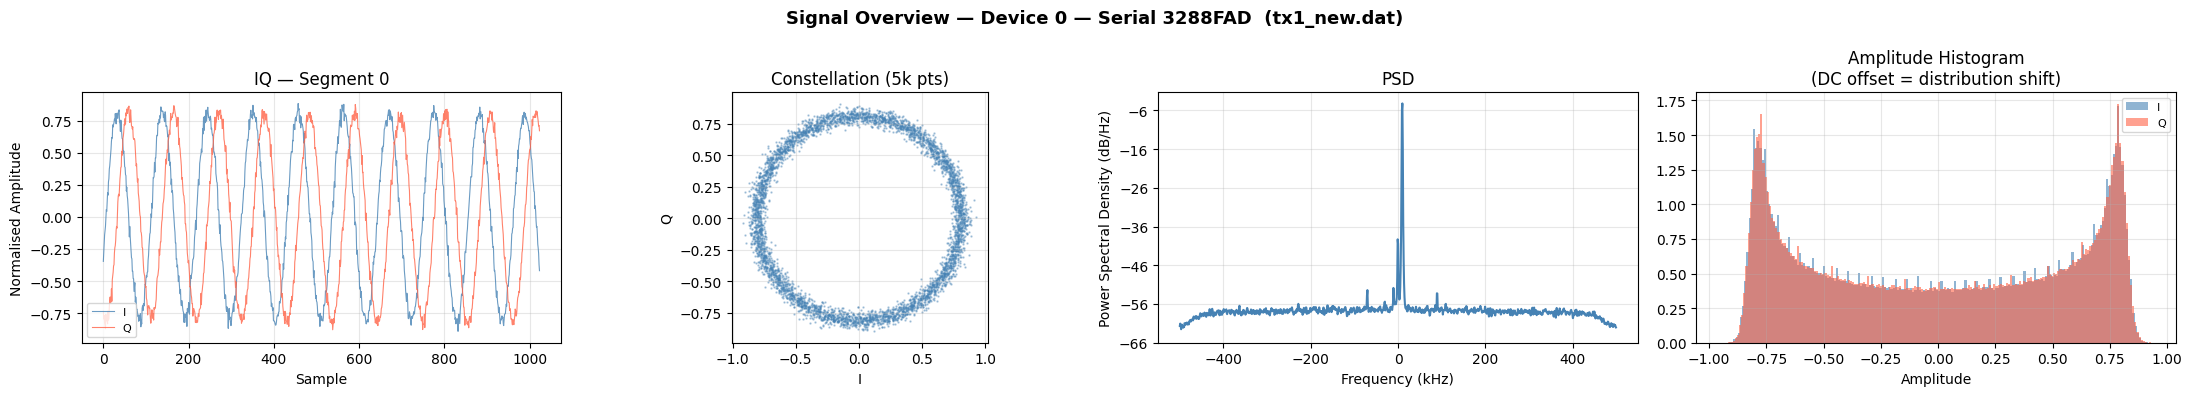

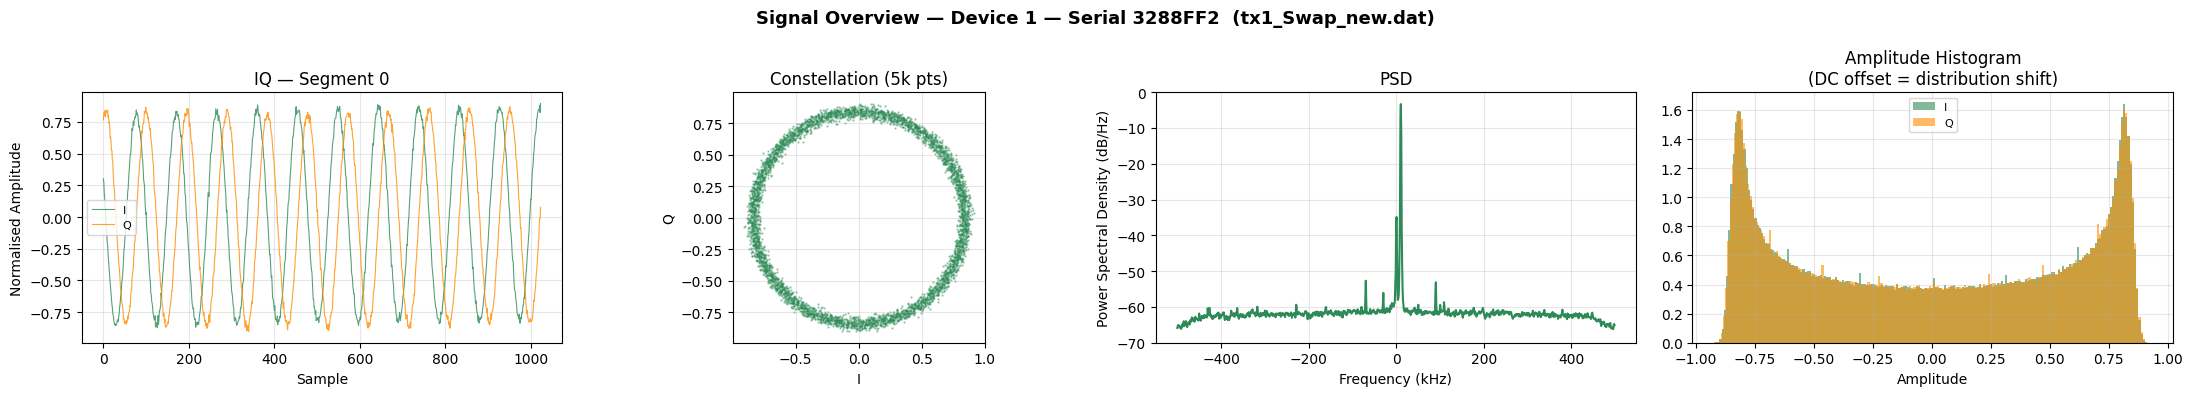

In [ ]:
def plot_signal_overview(raw_iq, segments, label, color_i='steelblue', color_q='tomato'):
    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f'Signal Overview — {label}', fontsize=13, fontweight='bold')

    # 1. IQ time-domain (first segment)
    ax = axes[0]
    ax.plot(segments[0, :, 0], color=color_i, alpha=0.8, label='I', linewidth=0.8)
    ax.plot(segments[0, :, 1], color=color_q, alpha=0.8, label='Q', linewidth=0.8)
    ax.set_title('IQ — Segment 0')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Normalised Amplitude')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # 2. Constellation (first 5000 raw samples)
    ax = axes[1]
    n = min(5000, len(raw_iq))
    ax.scatter(np.real(raw_iq[:n]), np.imag(raw_iq[:n]),
               s=0.5, alpha=0.4, color=color_i)
    ax.set_title('Constellation (5k pts)')
    ax.set_xlabel('I')
    ax.set_ylabel('Q')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # 3. Power Spectral Density
    ax = axes[2]
    ax.psd(raw_iq[:100_000], NFFT=1024, Fs=SAMPLE_RATE/1e3, color=color_i)
    ax.set_title('PSD')
    ax.set_xlabel('Frequency (kHz)')
    ax.grid(True, alpha=0.3)

    # 4. Amplitude histogram  — DC offset visible as non-zero mean
    ax = axes[3]
    ax.hist(np.real(raw_iq[:500_000]), bins=200, color=color_i, alpha=0.6, label='I', density=True)
    ax.hist(np.imag(raw_iq[:500_000]), bins=200, color=color_q, alpha=0.6, label='Q', density=True)
    ax.set_title('Amplitude Histogram\n(DC offset = distribution shift)')
    ax.set_xlabel('Amplitude')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_signal_overview(raw_tx1, segs_tx1, 'Device 0 — Serial 3288FAD  (tx1_new.dat)')
plot_signal_overview(raw_tx2, segs_tx2, 'Device 1 — Serial 3288FF2  (tx1_Swap_new.dat)',
                     color_i='seagreen', color_q='darkorange')

### DC Offset Comparison — Key Fingerprint Feature

In [ ]:
print("DC Offset (mean IQ) — this MUST differ between devices to be a fingerprint:")
print()

for name, iq in [("Device 0 (3288FAD)", raw_tx1), ("Device 1 (3288FF2)", raw_tx2)]:
    dc_i = np.mean(np.real(iq))
    dc_q = np.mean(np.imag(iq))
    magnitude = np.sqrt(dc_i**2 + dc_q**2)
    print(f"  {name}")
    print(f"    DC_I = {dc_i:+.6f}   DC_Q = {dc_q:+.6f}   |DC| = {magnitude:.6f}")
    print()

print("If both values are near zero and identical — the DC offset was removed (bad).")
print("If they differ — good, the LO leakage fingerprint is intact.")

DC Offset (mean IQ) — this MUST differ between devices to be a fingerprint:

  Device 0 (3288FAD)
    DC_I = -0.000259   DC_Q = -0.000249   |DC| = 0.000359

  Device 1 (3288FF2)
    DC_I = -0.000259   DC_Q = -0.000248   |DC| = 0.000359

If both values are near zero and identical — the DC offset was removed (bad).
If they differ — good, the LO leakage fingerprint is intact.


## Step 7 — AWGN Injection

For each SNR level we:
1. Measure **true signal power** from clean segments
2. Calculate required noise power: `noise_power = signal_power / 10^(SNR/10)`
3. Split noise equally across I and Q channels: `noise_std = sqrt(noise_power / 2)`
4. Verify artificial noise **dominates** real ambient noise

In [ ]:
def inject_awgn(segments, snr_db):
    """Add AWGN to segments to simulate a target SNR."""
    complex_sig  = segments[:, :, 0] + 1j * segments[:, :, 1]
    signal_power = np.mean(np.abs(complex_sig) ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise_std    = np.sqrt(noise_power / 2)
    noise        = np.random.normal(0, noise_std, segments.shape).astype(np.float32)
    return segments + noise


def measure_real_noise(segments):
    """Estimate ambient noise from amplitude variance (CW signal should be flat)."""
    complex_sig = segments[:, :, 0] + 1j * segments[:, :, 1]
    return np.var(np.abs(complex_sig))


print("AWGN Verification Report")
print("=" * 60)
for name, segs in [("Device 0", segs_tx1), ("Device 1", segs_tx2)]:
    complex_sig  = segs[:, :, 0] + 1j * segs[:, :, 1]
    sig_power    = np.mean(np.abs(complex_sig) ** 2)
    real_noise   = measure_real_noise(segs)
    print(f"\n{name}")
    print(f"  Signal Power     : {sig_power:.6f}")
    print(f"  Real Noise Est.  : {real_noise:.8f}")
    for snr in SNR_LEVELS:
        target = sig_power / (10 ** (snr / 10))
        status = "✅ AWGN dominates" if target > real_noise else "⚠️  Real noise too loud"
        print(f"  SNR {snr:3d} dB → target noise power {target:.6f}  {status}")

AWGN Verification Report

Device 0
  Signal Power     : 0.644448
  Real Noise Est.  : 0.00067973
  SNR  20 dB → target noise power 0.006444  ✅ AWGN dominates
  SNR  10 dB → target noise power 0.064445  ✅ AWGN dominates
  SNR   0 dB → target noise power 0.644448  ✅ AWGN dominates

Device 1
  Signal Power     : 0.700703
  Real Noise Est.  : 0.00055836
  SNR  20 dB → target noise power 0.007007  ✅ AWGN dominates
  SNR  10 dB → target noise power 0.070070  ✅ AWGN dominates
  SNR   0 dB → target noise power 0.700703  ✅ AWGN dominates


## Step 8 — Build Labelled Datasets (One Per SNR Level)

In [ ]:
def build_dataset(segs_class0, segs_class1, snr_db):
    """
    Inject AWGN, combine classes, create labels, split train/test.
    """
    noisy_0 = inject_awgn(segs_class0, snr_db)
    noisy_1 = inject_awgn(segs_class1, snr_db)

    X = np.concatenate([noisy_0, noisy_1], axis=0)
    y = np.concatenate([np.zeros(len(noisy_0), dtype=np.int32),
                        np.ones (len(noisy_1), dtype=np.int32)], axis=0)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y)

    print(f"  SNR {snr_db:3d} dB → train: {len(X_train):,}  test: {len(X_test):,}  "
          f"shape: {X_train.shape}")
    return X_train, X_test, y_train, y_test


print("Building datasets...")
datasets = {}
for snr in SNR_LEVELS:
    datasets[snr] = build_dataset(segs_tx1, segs_tx2, snr)

print("\nDone.")

Building datasets...
  SNR  20 dB → train: 98,891  test: 24,723  shape: (98891, 1024, 2)
  SNR  10 dB → train: 98,891  test: 24,723  shape: (98891, 1024, 2)
  SNR   0 dB → train: 98,891  test: 24,723  shape: (98891, 1024, 2)

Done.


## Step 9 — Lightweight 1D-CNN Architecture

Design rationale for thesis:
- **AveragePooling** (not Max) — preserves subtle phase/timing features important for RF fingerprinting
- **GlobalAveragePooling1D** instead of Flatten — reduces parameters from ~4M to ~52K total
- **3 Conv layers** progressively extract low→high level features
- **Dropout 0.5** — prevents overfitting on hardware-specific patterns
- **Adam lr=0.0001** — small steps for subtle RF feature landscape

In [ ]:
def build_cnn(input_shape=(SEGMENT_LENGTH, 2), num_classes=2):
    model = models.Sequential([
        # Block 1 — low-level feature extraction (phase, timing edges)
        layers.Conv1D(32, 7, activation='relu', padding='same',
                      input_shape=input_shape, name='conv1'),
        layers.AveragePooling1D(2, name='pool1'),

        # Block 2 — mid-level patterns
        layers.Conv1D(64, 5, activation='relu', padding='same', name='conv2'),
        layers.AveragePooling1D(2, name='pool2'),

        # Block 3 — high-level fingerprint features
        layers.Conv1D(128, 3, activation='relu', padding='same', name='conv3'),
        layers.AveragePooling1D(2, name='pool3'),

        # Aggregate over time — key to keeping parameter count low
        layers.GlobalAveragePooling1D(name='gap'),

        layers.Dense(128, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='RF_Fingerprint_CNN')

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Print summary once
demo_model = build_cnn()
demo_model.summary()

total_params = demo_model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"Target was ~45-55K — {'✅ within range' if total_params < 60000 else '⚠️ check architecture'}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "RF_Fingerprint_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 1024, 32)       │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling1D)        │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 512, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling1D)        │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 256, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (AveragePooling1D)        │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,258 (204.13 KB)

 Trainable params: 52,258 (204.13 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 52,258
Target was ~45-55K — ✅ within range


## Step 10 — Train One Model Per SNR Level

In [ ]:
results = {}   # stores history + test metrics per SNR

for snr in SNR_LEVELS:
    print("\n" + "=" * 60)
    print(f"  Training at SNR = {snr} dB")
    print("=" * 60)

    X_train, X_test, y_train, y_test = datasets[snr]

    model = build_cnn()

    early_stop = callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1)

    lr_reduce = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1)

    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, lr_reduce],
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    results[snr] = {
        'history': history,
        'model'  : model,
        'test_acc': acc,
        'test_loss': loss,
        'y_test' : y_test,
        'y_pred' : y_pred,
        'X_test' : X_test
    }

    print(f"\n  ✅ Final test accuracy at {snr} dB SNR: {acc*100:.2f}%")

print("\n" + "=" * 60)
print("All training runs complete.")
print("=" * 60)


  Training at SNR = 20 dB
Epoch 1/20
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8172 - loss: 0.4136 - val_accuracy: 1.0000 - val_loss: 0.0221 - learning_rate: 1.0000e-04
Epoch 2/20
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 9.7624e-04 - learning_rate: 1.0000e-04
Epoch 3/20
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 1.6502e-04 - learning_rate: 1.0000e-04
Epoch 4/20
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 1.0000 - loss: 3.3212e-04 - val_accuracy: 1.0000 - val_loss: 3.9702e-05 - learning_rate: 1.0000e-04
Epoch 5/20
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 1.0000 - loss: 1.2163e-04 - val_accuracy: 1.0000 - val_loss: 1.7768e-05 - learning_rate: 1.0000e-04
Epoch 6/20
1546/1546 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 1.0000 - loss: 4.7386e-05 - val_accuracy: 1.0000 - val_loss: 2.4717e-06 - learnin

## Step 11 — Training Curves

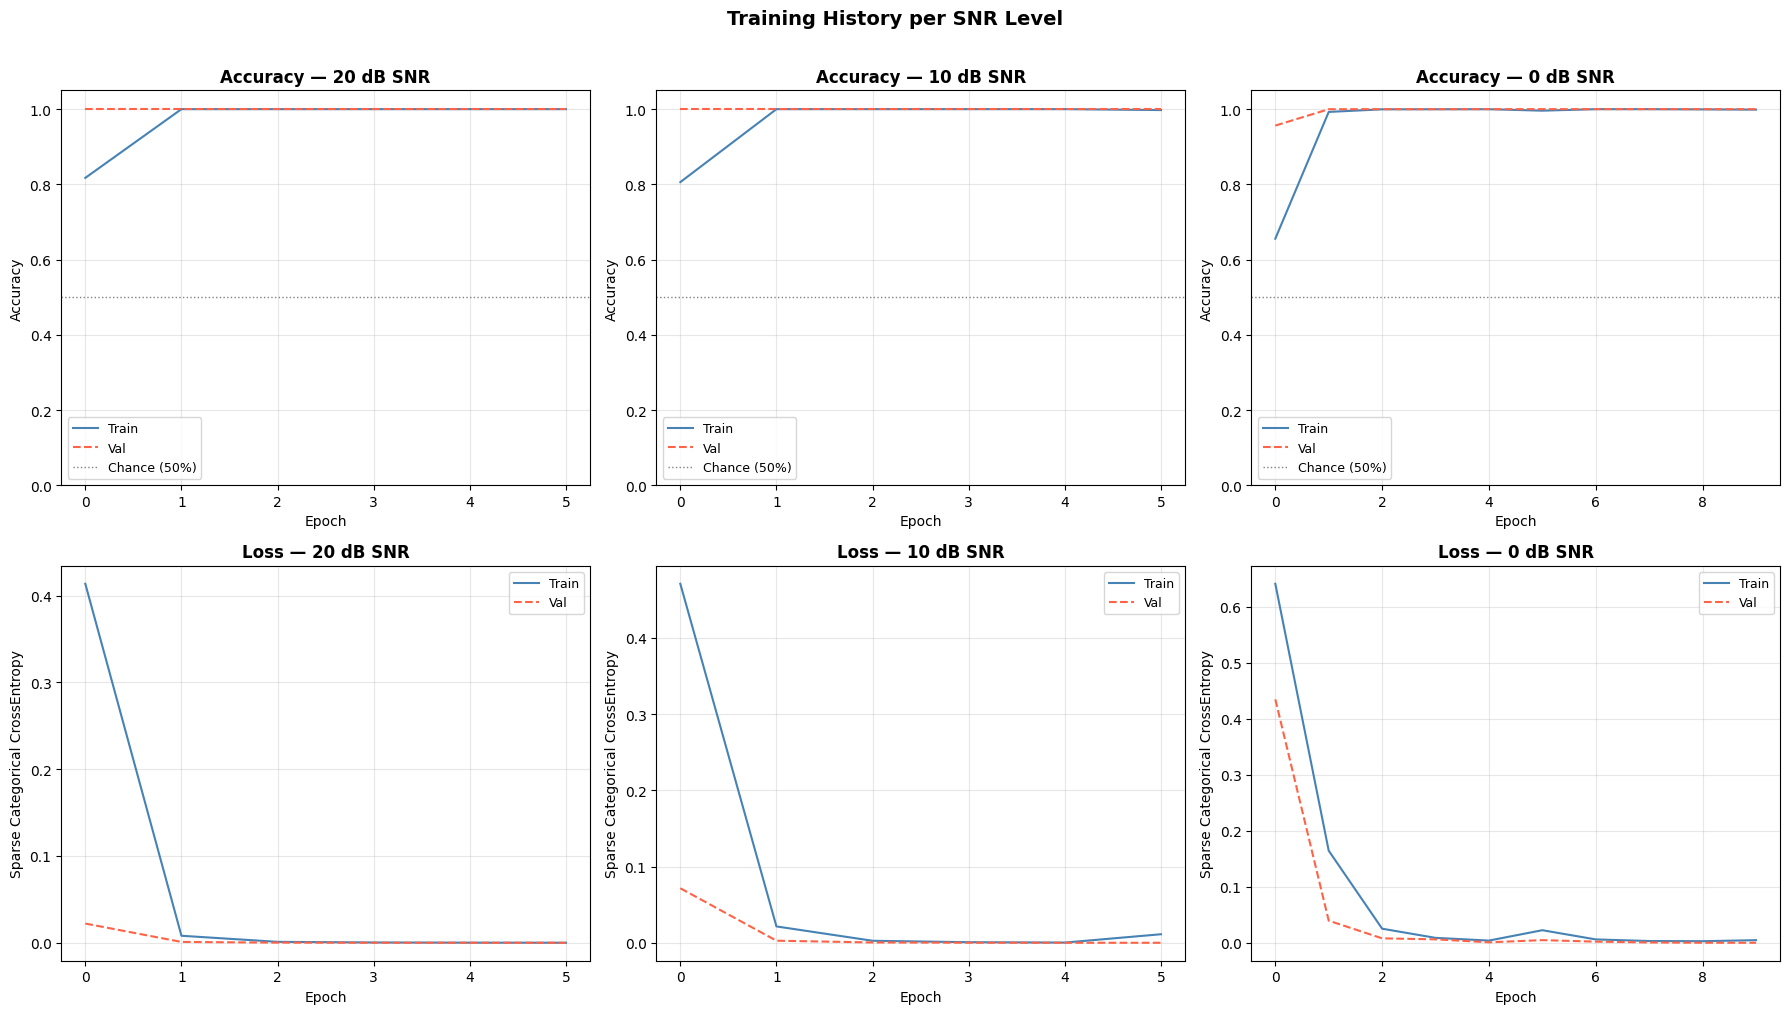

In [ ]:
fig, axes = plt.subplots(2, len(SNR_LEVELS), figsize=(6*len(SNR_LEVELS), 10))
fig.suptitle('Training History per SNR Level', fontsize=14, fontweight='bold', y=1.01)

for col, snr in enumerate(SNR_LEVELS):
    h = results[snr]['history'].history

    # Accuracy
    ax = axes[0][col]
    ax.plot(h['accuracy'],     label='Train', color='steelblue', linewidth=1.5)
    ax.plot(h['val_accuracy'], label='Val',   color='tomato',    linewidth=1.5, linestyle='--')
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='Chance (50%)')
    ax.set_title(f'Accuracy — {snr} dB SNR', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Loss
    ax = axes[1][col]
    ax.plot(h['loss'],     label='Train', color='steelblue', linewidth=1.5)
    ax.plot(h['val_loss'], label='Val',   color='tomato',    linewidth=1.5, linestyle='--')
    ax.set_title(f'Loss — {snr} dB SNR', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Sparse Categorical CrossEntropy')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 12 — Confusion Matrices

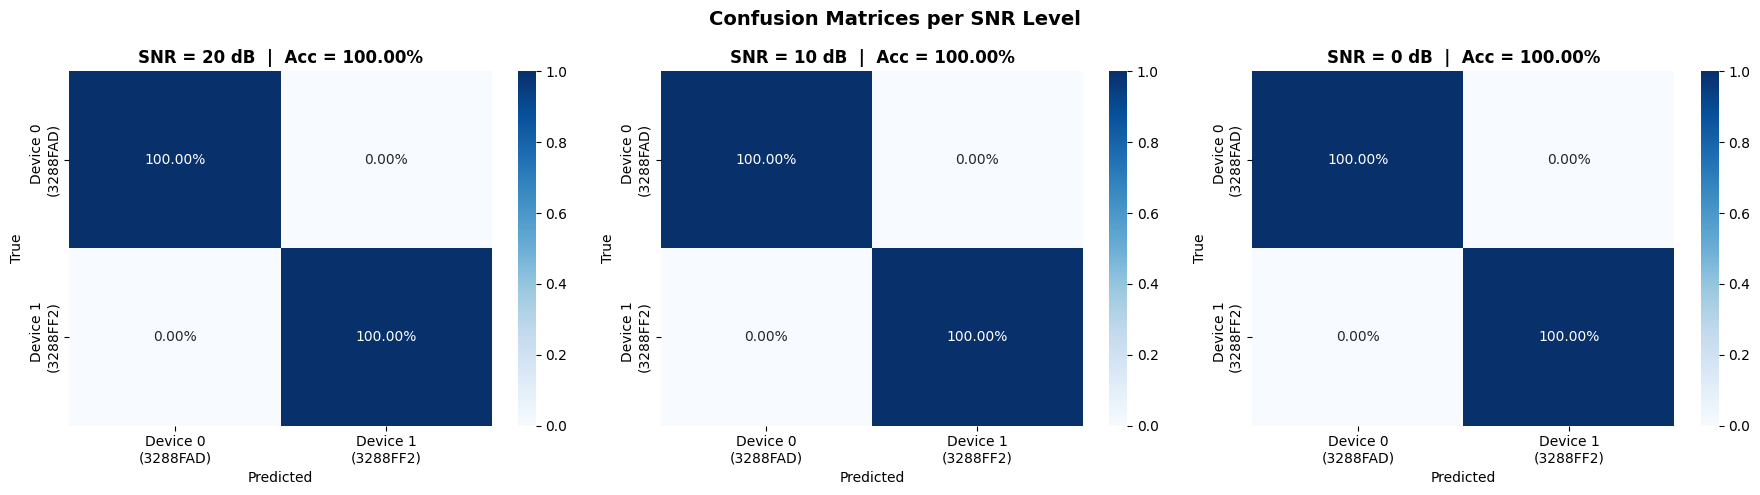

In [ ]:
fig, axes = plt.subplots(1, len(SNR_LEVELS), figsize=(6*len(SNR_LEVELS), 5))
fig.suptitle('Confusion Matrices per SNR Level', fontsize=14, fontweight='bold')

CLASS_NAMES = ['Device 0\n(3288FAD)', 'Device 1\n(3288FF2)']

for col, snr in enumerate(SNR_LEVELS):
    cm = confusion_matrix(results[snr]['y_test'], results[snr]['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    ax = axes[col] if len(SNR_LEVELS) > 1 else axes
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=True, vmin=0, vmax=1)
    ax.set_title(f'SNR = {snr} dB  |  Acc = {results[snr]["test_acc"]*100:.2f}%',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

## Step 13 — Per-SNR Accuracy Summary (Thesis Figure)


╔══════════════════════════════════════╗
║   RF Fingerprinting — Results Summary  ║
╠══════════╦═════════════════════════════╣
║  SNR (dB) ║  Test Accuracy             ║
╠══════════╬═════════════════════════════╣
║      20 dB ║  100.00%  ████████████████████║
║      10 dB ║  100.00%  ████████████████████║
║       0 dB ║  100.00%  ████████████████████║
╚══════════╩═════════════════════════════╝


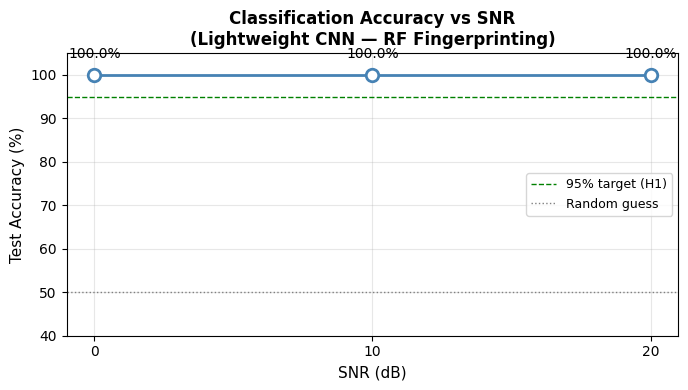

In [ ]:
snr_vals = SNR_LEVELS
acc_vals = [results[s]['test_acc'] * 100 for s in SNR_LEVELS]

print("\n╔══════════════════════════════════════╗")
print("║   RF Fingerprinting — Results Summary  ║")
print("╠══════════╦═════════════════════════════╣")
print("║  SNR (dB) ║  Test Accuracy             ║")
print("╠══════════╬═════════════════════════════╣")
for snr, acc in zip(snr_vals, acc_vals):
    bar = '█' * int(acc / 5)
    print(f"║  {snr:6} dB ║  {acc:6.2f}%  {bar:<20}║")
print("╚══════════╩═════════════════════════════╝")

# Line plot for thesis
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(snr_vals, acc_vals, 'o-', color='steelblue', linewidth=2,
        markersize=9, markerfacecolor='white', markeredgewidth=2)
ax.axhline(95, color='green',  linestyle='--', linewidth=1, label='95% target (H1)')
ax.axhline(50, color='grey',   linestyle=':', linewidth=1,  label='Random guess')
for snr, acc in zip(snr_vals, acc_vals):
    ax.annotate(f'{acc:.1f}%', (snr, acc), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10)
ax.set_title('Classification Accuracy vs SNR\n(Lightweight CNN — RF Fingerprinting)',
             fontweight='bold')
ax.set_xlabel('SNR (dB)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_ylim([40, 105])
ax.set_xticks(snr_vals)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 14 — Detailed Classification Report

In [ ]:
for snr in SNR_LEVELS:
    print(f"\n{'='*50}")
    print(f"  SNR = {snr} dB")
    print(f"{'='*50}")
    print(classification_report(
        results[snr]['y_test'],
        results[snr]['y_pred'],
        target_names=['Device 0 (3288FAD)', 'Device 1 (3288FF2)']
    ))


  SNR = 20 dB
                    precision    recall  f1-score   support

Device 0 (3288FAD)       1.00      1.00      1.00     12302
Device 1 (3288FF2)       1.00      1.00      1.00     12421

          accuracy                           1.00     24723
         macro avg       1.00      1.00      1.00     24723
      weighted avg       1.00      1.00      1.00     24723


  SNR = 10 dB
                    precision    recall  f1-score   support

Device 0 (3288FAD)       1.00      1.00      1.00     12302
Device 1 (3288FF2)       1.00      1.00      1.00     12421

          accuracy                           1.00     24723
         macro avg       1.00      1.00      1.00     24723
      weighted avg       1.00      1.00      1.00     24723


  SNR = 0 dB
                    precision    recall  f1-score   support

Device 0 (3288FAD)       1.00      1.00      1.00     12302
Device 1 (3288FF2)       1.00      1.00      1.00     12421

          accuracy                           1.0

## Step 15 — Save Trained Models

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/My Thesis/Models'
os.makedirs(SAVE_PATH, exist_ok=True)

for snr in SNR_LEVELS:
    path = os.path.join(SAVE_PATH, f'rf_cnn_snr{snr}dB.keras')
    results[snr]['model'].save(path)
    print(f"Saved: {path}")

print("\nAll models saved.")

Saved: /content/drive/MyDrive/My Thesis/Models/rf_cnn_snr20dB.keras
Saved: /content/drive/MyDrive/My Thesis/Models/rf_cnn_snr10dB.keras
Saved: /content/drive/MyDrive/My Thesis/Models/rf_cnn_snr0dB.keras

All models saved.
